In [1]:
import pandas as pd
import numpy as np
from os import listdir
import re

import matplotlib.pyplot as plt

# Voice Actors

In [2]:
FOLDER = 'Roles/VA'

FILENAMES = [f'{FOLDER}/{file}' for file in listdir(FOLDER)[1:]]
len(FILENAMES)

5585

In [3]:
def CompileCSV(FOLDER : str):
    FILENAMES = [f'{FOLDER}/{file}' for file in listdir(FOLDER)[1:]]
    FILENAMES
    
    output = None
    
    for f in FILENAMES:
        if f[-4:] != '.csv':
            continue
    
        df = None
    
        ID, NAME = f.split('/')[-1].strip('.csv').split('_')
    
        df = pd.read_csv(f)
        df['Personnel_ID'] = int(ID)
        df['Personnel_Name'] = NAME
    
    
        if output is None:
            output = df.copy()
        else:
            output = pd.concat([output, df])

    return output

In [4]:
df_VA = CompileCSV(FOLDER).reset_index().drop(columns=['index'])
df_VA

,ID,Title,Link,Type,Season,Year,Character,CharacterLink,CharacterID,CharacterRole,CharacterFavorites,Personnel_ID,Personnel_Name
0,3588,Soul Eater,https://myanimelist.net/anime/3588/Soul_Eater,TV,Spring,2008.0,Excalibur,https://myanimelist.net/character/13046/Excalibur,13046,Supporting,1574,10002,Rajkai Zoltán
1,27,Trinity Blood,https://myanimelist.net/anime/27/Trinity_Blood,TV,Spring,2005.0,"Nightroad, Abel",https://myanimelist.net/character/1672/Abel_Ni...,1672,Main,974,10002,Rajkai Zoltán
2,20,Naruto,https://myanimelist.net/anime/20/Naruto,TV,Fall,2002.0,"Gekkou, Hayate",https://myanimelist.net/character/7738/Hayate_...,7738,Supporting,54,10002,Rajkai Zoltán
3,47,Akira,https://myanimelist.net/anime/47/Akira,Movie,NaN,1988.0,Yamagata,https://myanimelist.net/character/20463/Yamagata,20463,Supporting,13,10002,Rajkai Zoltán
4,523,Tonari no Totoro,https://myanimelist.net/anime/523/Tonari_no_To...,Movie,NaN,1988.0,"Kusakabe, Tatsuo",https://myanimelist.net/character/8047/Tatsuo_...,8047,Supporting,25,10002,Rajkai Zoltán
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261602,1960,Sore Ike! Anpanman,https://myanimelist.net/anime/1960/Sore_Ike_An...,TV,Fall,1988.0,Numatchi,https://myanimelist.net/character/114765/Numatchi,114765,Supporting,0,9,Mitsuishi Kotono
261603,1960,Sore Ike! Anpanman,https://myanimelist.net/anime/1960/Sore_Ike_An...,TV,Fall,1988.0,Marron-kun,https://myanimelist.net/character/196687/Marro...,196687,Supporting,0,9,Mitsuishi Kotono
261604,1960,Sore Ike! Anpanman,https://myanimelist.net/anime/1960/Sore_Ike_An...,TV,Fall,1988.0,Kaginoko Key-chan,https://myanimelist.net/character/197241/Kagin...,197241,Supporting,0,9,Mitsuishi Kotono
261605,1960,Sore Ike! Anpanman,https://myanimelist.net/anime/1960/Sore_Ike_An...,TV,Fall,1988.0,Kittelion,https://myanimelist.net/character/197260/Kitte...,197260,Supporting,0,9,Mitsuishi Kotono


In [7]:
df_VA.drop(columns=['Link', 'CharacterLink'], inplace=True)
df_VA.rename(columns={
    'ID': 'Anime_ID',
    'CharacterID' : 'Character_ID',
    'CharacterRole' : 'Role',
    'CharacterFavorites' : 'Character_Favorites',
                     }, inplace=True)

### Remove Irrelevant Characters

In [8]:
MIN_FAVORITES = 1
df_VA = df_VA[df_VA.Character_Favorites >= MIN_FAVORITES]
df_VA.shape

(168357, 11)

## Extract the VA IDs

In [35]:
df_PersonnelsVA = df_VA.copy()
df_PersonnelsVA.Character = df_PersonnelsVA.Character.replace(',', '', regex=True)
df_PersonnelsVA = pd.merge(df_PersonnelsVA.groupby(['Personnel_ID', 'Personnel_Name'])[['Character', 'Character_ID', 'Title', 'Anime_ID']].agg(list).reset_index().set_index('Personnel_ID'),
         df_PersonnelsVA.groupby(['Personnel_ID']).Year.max(),
         on='Personnel_ID',
        how='left').rename(columns={'Year': 'Latest_Work'})

df_PersonnelsVA.to_pickle('Roles_Extracted/Personnels_VA.pkl')
df_PersonnelsVA

,Personnel_Name,Character,Character_ID,Title,Anime_ID,Latest_Work
Personnel_ID,,,,,,
1,Seki Tomokazu,"[Shinazugawa Sanemi, Hoshimiya Rekka, Honekawa...","[151149, 140499, 8261, 8079, 73589, 2514, 2606...","[Kimetsu no Yaiba Movie: Mugen Jou-hen, Enen n...","[59192, 51818, 59980, 59914, 59226, 55830, 568...",2025.0
2,Sugita Tomokazu,"[Sakata Gintoki, Smart Ansem, Himejima Gyoumei...","[672, 251334, 151146, 187171, 119733, 33788, 1...","[3-nen Z-gumi Ginpachi-sensei, Nageki no Boure...","[54757, 60619, 59192, 60083, 59406, 59914, 589...",2025.0
3,Yukino Satsuki,"[Shimura Tae, Shimura Tae, Hiiragi, Shihouin Y...","[2944, 2944, 19023, 908, 87115, 151102, 908, 1...","[3-nen Z-gumi Ginpachi-sensei, Gintama on Thea...","[54757, 59688, 55823, 56784, 57864, 56785, 539...",2025.0
4,Hirano Aya,"[Antoinette Marie, Antoinette Marie, Kazamaki ...","[1701, 1701, 256815, 6273, 5186, 14117, 5186, ...","[Versailles no Bara (Movie), Verbara Mini!, Ma...","[52967, 60783, 59632, 56894, 60063, 56538, 497...",2025.0
5,Suzumura Kenichi,"[Okita Sougo, Iguro Obanai, Hinawa Takehisa, S...","[2282, 151148, 133771, 42711, 194489, 51153, 2...","[3-nen Z-gumi Ginpachi-sensei, Kimetsu no Yaib...","[54757, 59192, 51818, 50855, 57217, 49785, 557...",2025.0
...,...,...,...,...,...,...
52309,Ootani Rinka,[Woodward Nathalie],[165314],[Eiga Daisuki Pompo-san],[41361],2021.0
52315,Tarsha Nazeeh H,"[Sanada Tooru, Ebio, Hibino Kafka, Grucius, As...","[16725, 231714, 187463, 188115, 197441, 177632...","[Kimi ni Todoke 3rd Season, Shy 2nd Season, Ka...","[56538, 57567, 52588, 53580, 55866, 51180, 538...",2024.0
52317,Stewart Kylie,"[Steinberg Mary, Rock Lock's Wife, Steinberg M...","[166835, 178658, 166835, 173873, 169968]","[No Guns Life 2nd Season, Boku no Hero Academi...","[40529, 38408, 39539, 38297, 34620]",2020.0


### Continue Cleaning df_VA

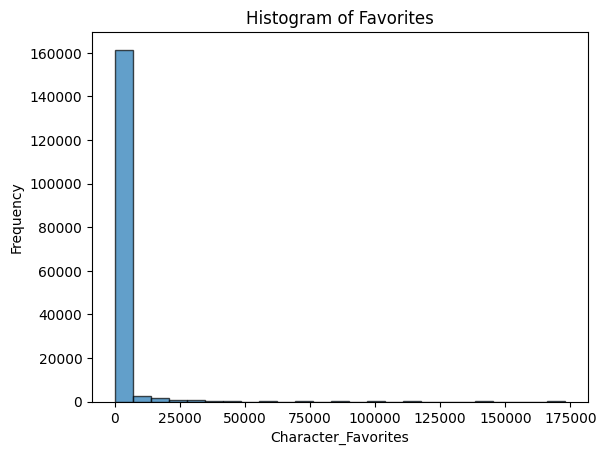

In [10]:
df_VA['Character_Favorites'].plot(kind='hist', bins=25, edgecolor='black', alpha=0.7)
plt.title('Histogram of Favorites')
plt.xlabel('Character_Favorites')
plt.show()

In [11]:
df_VA.Role.value_counts()

Role
Supporting    116375
Main           51982
Name: count, dtype: int64

In [12]:
df_VA = pd.get_dummies(df_VA, columns=['Role'])

In [13]:
df_VA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 168357 entries, 0 to 261606
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Anime_ID             168357 non-null  int64  
 1   Title                168357 non-null  object 
 2   Type                 168047 non-null  object 
 3   Season               104233 non-null  object 
 4   Year                 168047 non-null  float64
 5   Character            168357 non-null  object 
 6   Character_ID         168357 non-null  int64  
 7   Character_Favorites  168357 non-null  int64  
 8   Personnel_ID         168357 non-null  int64  
 9   Personnel_Name       168357 non-null  object 
 10  Role_Main            168357 non-null  bool   
 11  Role_Supporting      168357 non-null  bool   
dtypes: bool(2), float64(1), int64(4), object(5)
memory usage: 14.5+ MB


In [ ]:
df_VA.to_csv('Roles_Extracted/VA_Raw.csv')

In [ ]:
df_VA_MBA = pd.DataFrame(df_VA.groupby('Anime_ID')[['Title', 'Personnel_ID', 'Personnel_Name', 'Character']].agg(list))
df_VA_MBA['Title'] = df_VA_MBA['Title'].apply(lambda x : x[0])

df_VA_MBA.to_pickle('Roles_Extracted/MBA_VA.pkl')
df_VA_MBA

# Staff

In [ ]:
FOLDER = 'Roles/Staff'

FILENAMES = [f'{FOLDER}/{file}' for file in listdir(FOLDER)[1:]]
len(FILENAMES)

In [ ]:
df_Staff = CompileCSV(FOLDER).reset_index().drop(columns=['index'])
df_Staff

## Extract the Staff IDs

In [ ]:
df_PersonnelsStaff = pd.DataFrame(index = df_VA.set_index(['Personnel_ID', 'Personnel_Name']).sort_index().index.unique())
df_PersonnelsStaff.to_csv('Roles_Extracted/Personnels_Staff.csv')
df_PersonnelsStaff

### Continue cleaning

In [ ]:
df_Staff.drop(columns=['Link'], inplace=True)
df_Staff.rename(columns={'ID':'Anime_ID'}, inplace=True)

In [ ]:
df_Staff.info()

### Although some Anime Scores are null, their Members are all complete.

In [ ]:
df_Staff[df_Staff.Score.isna()]

## One Hot Encode the Roles

In [ ]:
def filter_strings(strings, exclude_words, replace_words):
    filtered_strings = set()  
    
    for s in strings:
        if any(word in s for word in exclude_words):
            continue

        if any(word in s for word in replace_words):
            for w in replace_words:
                s = s.replace(w, '')
            
        filtered_strings.add(s)
    
    return list(filtered_strings)

In [ ]:
ROLES = filter_strings(df_Staff.Roles, ['(', ',', ')', 'Original Creator'], [])
ROLES

In [ ]:
df_OneHotStaffRoles = pd.DataFrame(columns=ROLES)

for role_String in df_Staff.Roles:
    df_OneHotStaffRoles.loc[len(df_OneHotStaffRoles)] = [1 if r in role_String else 0 for r in ROLES]

df_OneHotStaffRoles.head()

In [ ]:
print(df_OneHotStaffRoles.sum().sort_values(ascending=False))

df_OneHotStaffRoles.sum().sort_values(ascending=False)[:20].plot(kind='bar', edgecolor='black', alpha=0.7)
plt.title('Top 20 Staff Roles')
plt.show()

In [ ]:
df_Staff = df_Staff.reset_index().drop(columns=['index', 'Roles']).join(
    df_OneHotStaffRoles
)
df_Staff

In [ ]:
df_Staff.to_csv('Roles_Extracted/Staff_Raw.csv')

In [ ]:
df_Staff_MBA = df_Staff.copy()
df_Staff_MBA['Role'] = df_Staff_MBA.iloc[:,9:].idxmax(axis=1).str.replace('class_', '')

df_Staff_MBA = df_Staff_MBA[['Anime_ID', 'Title', 'Role', 'Personnel_ID', 'Personnel_Name']].groupby('Anime_ID').agg(list)
df_Staff_MBA['Title'] = df_Staff_MBA['Title'].apply(lambda x : x[0])
df_Staff_MBA.to_pickle('Roles_Extracted/MBA_Staff.pkl')
df_Staff_MBA